This is my first competition so I am pretty excited. All the best to everyone reading my kernel. Hope you get to learn something about this dataset through my kernel. Please upvote if you like the kernel. 

**Importing basic libraries and modules**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.plotly as py
from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
seed=5
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
import gc
import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['train_identity.csv', 'test_identity.csv', 'test_transaction.csv', 'sample_submission.csv', 'train_transaction.csv']


**Loading the data**

In [2]:
train_identity=pd.read_csv('../input/train_identity.csv',index_col='TransactionID')
test_identity=pd.read_csv('../input/test_identity.csv',index_col='TransactionID')
train_transaction=pd.read_csv('../input/train_transaction.csv',index_col='TransactionID')
test_transaction=pd.read_csv('../input/test_transaction.csv',index_col='TransactionID')
sub=pd.read_csv('../input/sample_submission.csv',index_col='TransactionID')

In [3]:
print('Shape of train identity :',train_identity.shape)
print('Shape of test identity :',test_identity.shape)
print('Shape of train transaction :',train_transaction.shape)
print('Shape of test transaction :',test_transaction.shape)

Shape of train identity : (144233, 40)
Shape of test identity : (141907, 40)
Shape of train transaction : (590540, 393)
Shape of test transaction : (506691, 392)


In [4]:
train_identity.head()

,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
train_transaction.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,...,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_df=pd.merge(train_identity,train_transaction,how='right',on='TransactionID')
test_df=pd.merge(test_identity,test_transaction,how='right',on='TransactionID')

**Important step not go out of RAM**

In [7]:
del train_identity,test_identity,train_transaction,test_transaction

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 590540 entries, 2987004 to 3577539
Columns: 433 entries, id_01 to V339
dtypes: float64(399), int64(3), object(31)
memory usage: 1.9+ GB


**Downcast the dataframes to free up upto 1 GB RAM. **

In [9]:
def downcast(df):
    float_cols=[col for col in df.columns if df[col].dtype=='float']
    df[float_cols]=df[float_cols].astype('float32')
    int_cols=[col for col in df.columns if df[col].dtype=='int']
    df[int_cols]=df[int_cols].astype('int16')
    return df    

In [10]:
train_df=downcast(train_df)
test_df=downcast(test_df)

**Save these downcasted dataframes becausing downcasting was time consuming**

In [11]:
train_df.to_csv('IEEE_train.csv')
test_df.to_csv('IEEE_test.csv')

In [12]:
print(train_df.shape)
print(test_df.shape)

(590540, 433)
(506691, 432)


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 590540 entries, 2987004 to 3577539
Columns: 433 entries, id_01 to V339
dtypes: float32(399), int16(3), object(31)
memory usage: 1.0+ GB


In [14]:
def null_values(df):
    series_1=pd.Series(df.isnull().sum(),name='Total null values')
    series_2=pd.Series(series_1*100/df.shape[0],name='Percentage of null values')
    null_df=pd.concat([series_1,series_2],axis=1).sort_values(by='Percentage of null values',ascending=False)
    return null_df

In [15]:
null_df=null_values(train_df)

In [16]:
null_df.head()

,Total null values,Percentage of null values
id_24,585793,99.196159
id_25,585408,99.130965
id_08,585385,99.127070
id_07,585385,99.127070
id_21,585381,99.126393


**Fill missing values of numerical features with their mean and that of categorical feature with their mode.**

In [17]:
def fill_missing(df):
    num_cols=[col for col in df.columns if df[col].dtype=='float32' or df[col].dtype=='int16']
    for col in num_cols:
        df[col]=df[col].fillna(df[col].mean())
    obj_cols=[col for col in df.columns if df[col].dtype=='object']
    for col in obj_cols:
        df[col]=df[col].fillna(df[col].mode()[0])
        
    return df

In [18]:
train_df=fill_missing(train_df)
test_df=fill_missing(test_df)

**Generate some  new features**

In [19]:
num_cols=[col for col in train_df.columns if train_df[col].dtype=='int16' or train_df[col].dtype=='float32']
num_cols.remove('isFraud')
train_df['mean']=train_df[num_cols].mean(axis=1)
test_df['mean']=test_df[num_cols].mean(axis=1)
train_df['max']=train_df[num_cols].max(axis=1)
test_df['max']=test_df[num_cols].max(axis=1)
train_df['min']=train_df[num_cols].min(axis=1)
test_df['min']=test_df[num_cols].min(axis=1)
train_df['median']=train_df[num_cols].median(axis=1)
test_df['median']=test_df[num_cols].median(axis=1)
train_df['skew']=train_df[num_cols].skew(axis=1)
test_df['skew']=test_df[num_cols].skew(axis=1)
train_df['kurt']=train_df[num_cols].kurt(axis=1)
test_df['kurt']=test_df[num_cols].kurt(axis=1)

**Visualizing all numerical features for Train and Test Data **

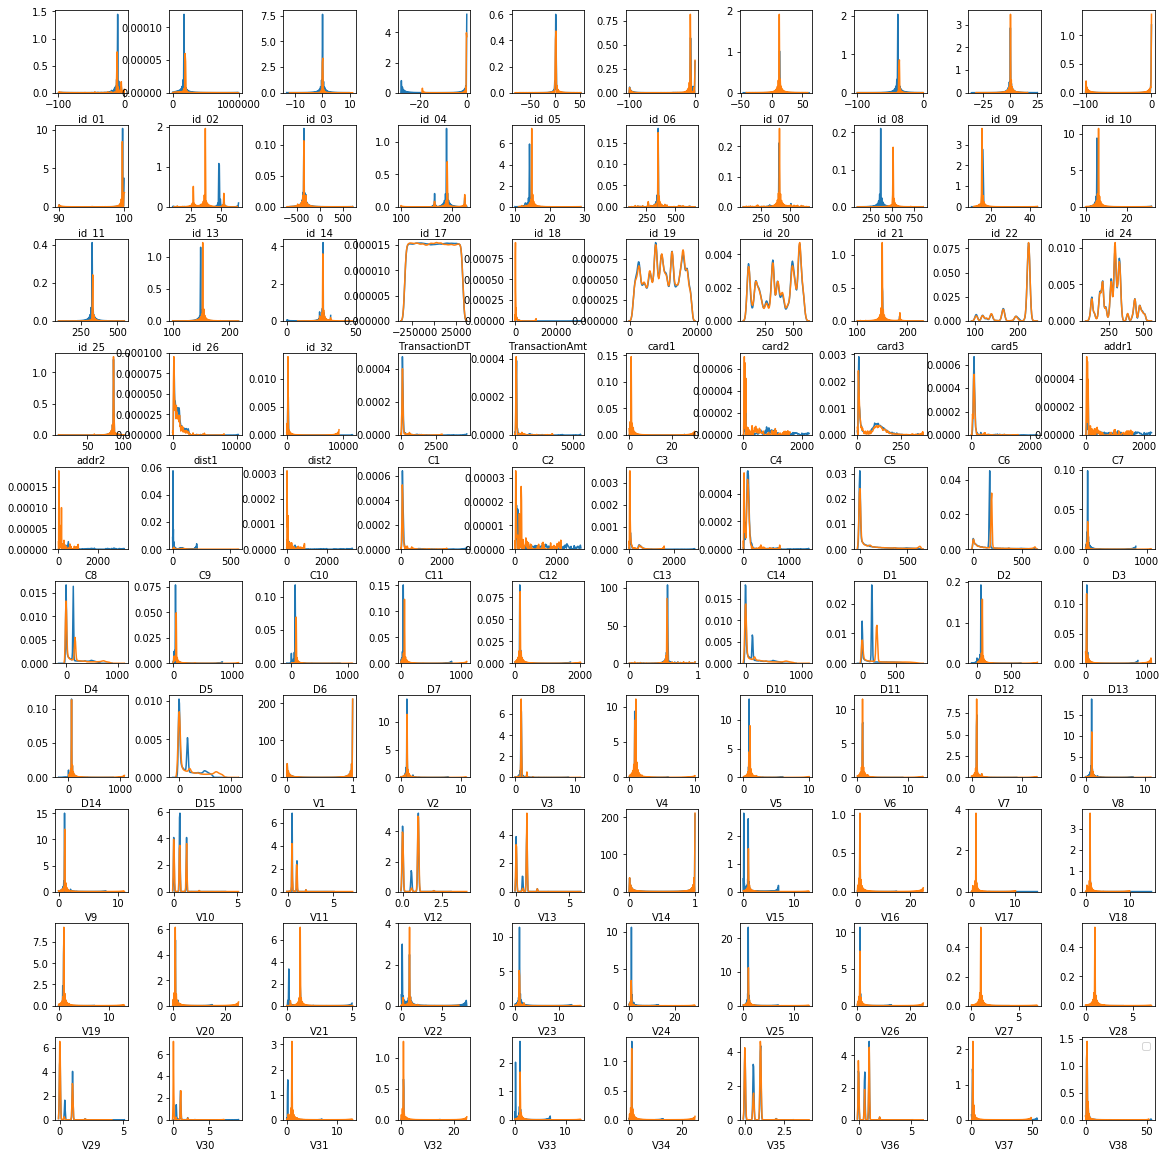

In [20]:
#blue represents train while orange represents test
#I had tried setting labels but the legends of adjacent plots used to overlap.
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[num_cols[i*10+j]],ax=ax[i,j],hist=False)
        sns.distplot(test_df[num_cols[i*10+j]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j])
        plt.legend()
        

plt.show()

Most of the train and test feature distributions look similar. Some distributions like that of TransactionDT, card1,card2,addr1,addr2,etc. almost exactly overlap, that's a bit strange I guess. Some distributions like that of C9,id13,id21(peaks at different value) are significantly different.

/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:487: RuntimeWarning:

invalid value encountered in true_divide

/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning:

invalid value encountered in double_scalars



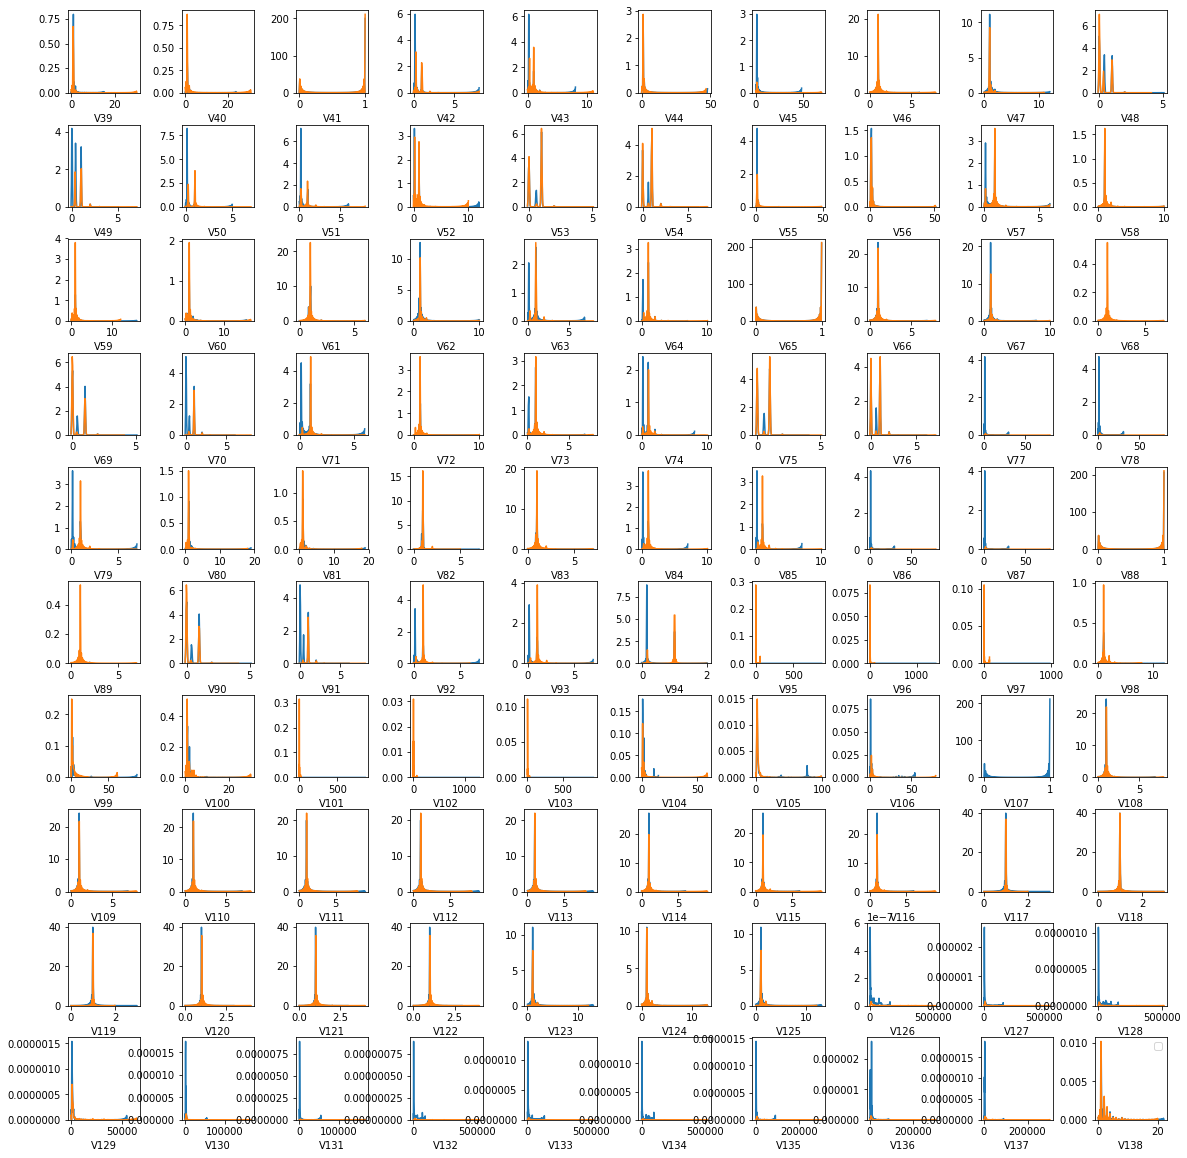

In [21]:
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[num_cols[i*10+j+100]],ax=ax[i,j],hist=False)
        sns.distplot(test_df[num_cols[i*10+j+100]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j+100])
        plt.legend()
        

plt.show()

Some distributions like that of V77,V78,V86,V87 are seemingly different. Here again, many look similar, some are just shifted versions while some are completely different. We do similar analysis for the rest of the numerical features.

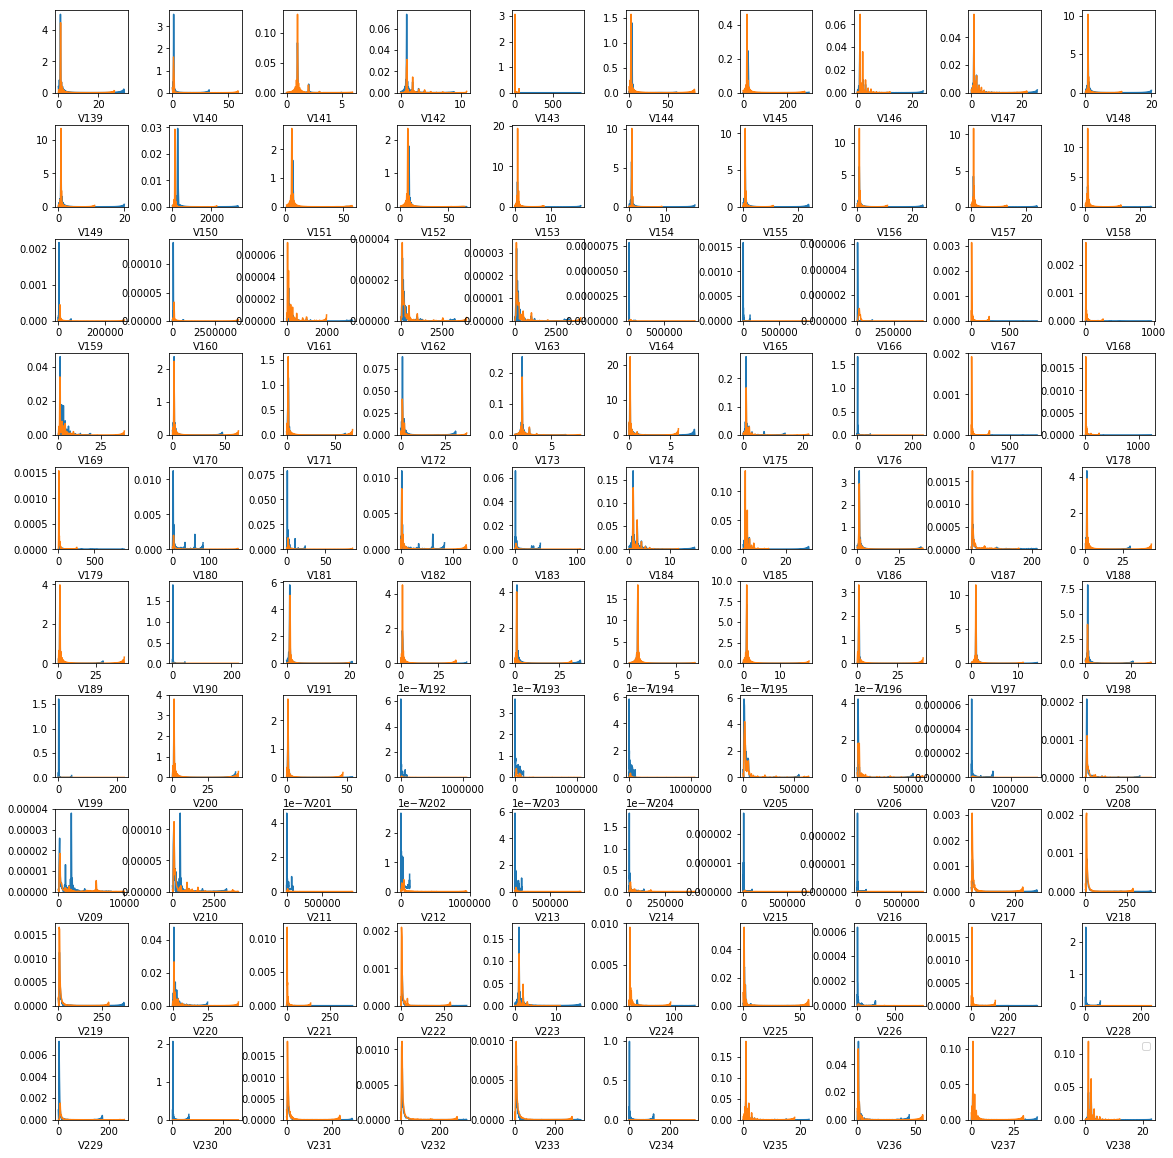

In [22]:
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[num_cols[i*10+j+200]],ax=ax[i,j],hist=False)
        sns.distplot(test_df[num_cols[i*10+j+200]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j+200])
        plt.legend()
        

plt.show()

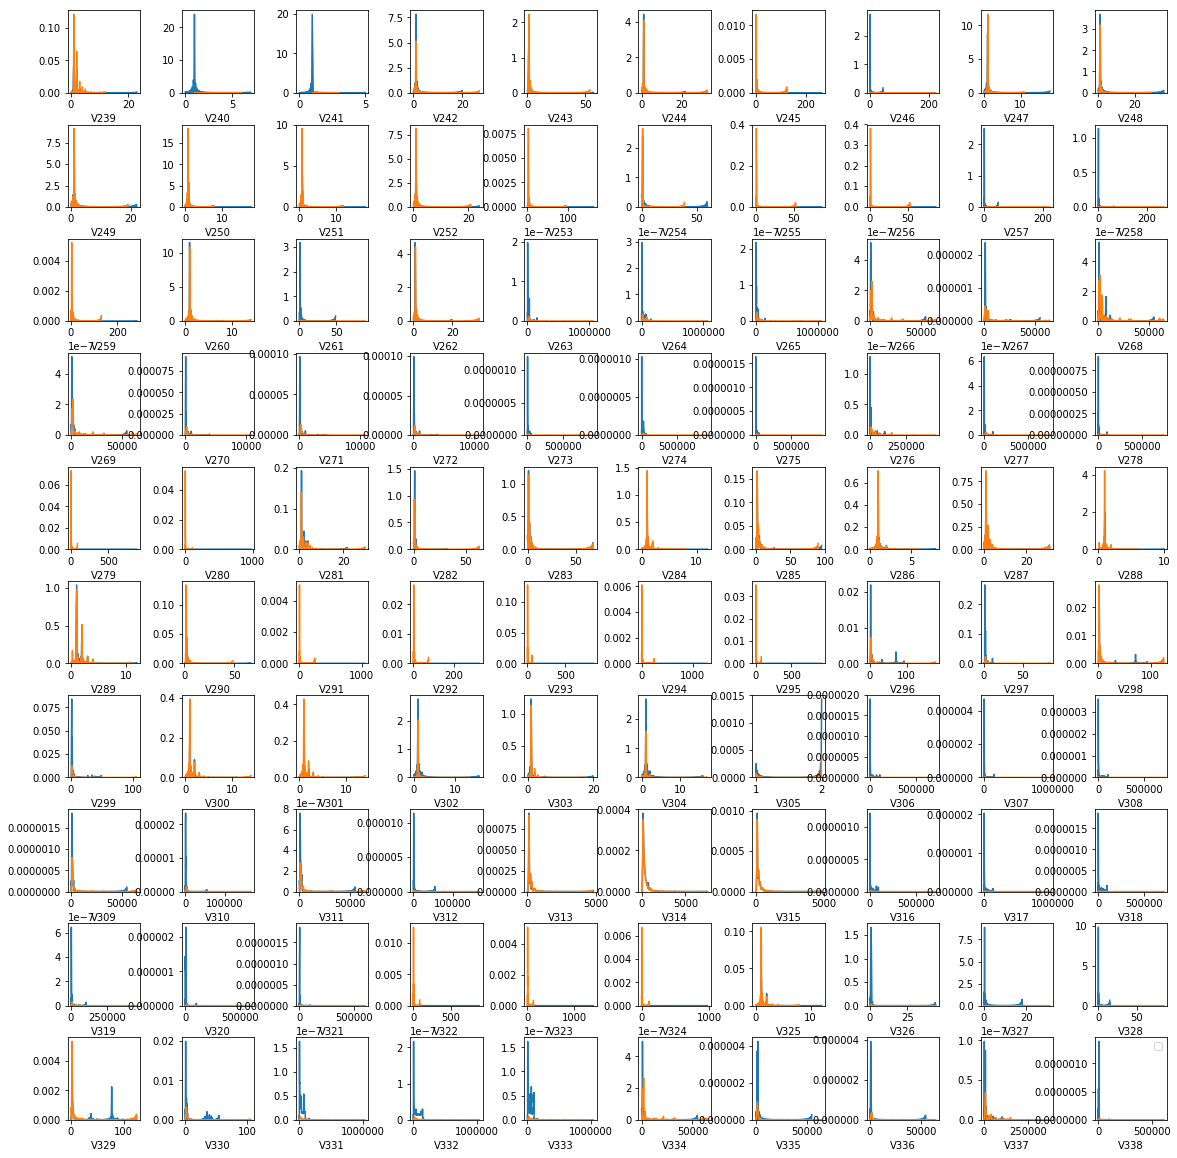

In [23]:
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[num_cols[i*10+j+300]],ax=ax[i,j],hist=False)
        sns.distplot(test_df[num_cols[i*10+j+300]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j+300])
        plt.legend()
        

plt.show()

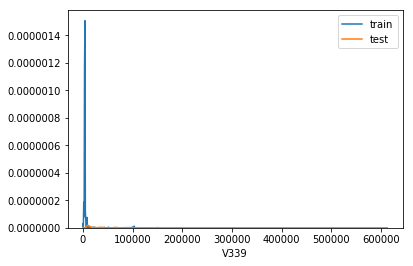

In [24]:
sns.distplot(train_df['V339'],label='train',hist=False)
sns.distplot(test_df['V339'],label='test',hist=False)
plt.legend()

**Visualizing all categorical features of Train and Test set**

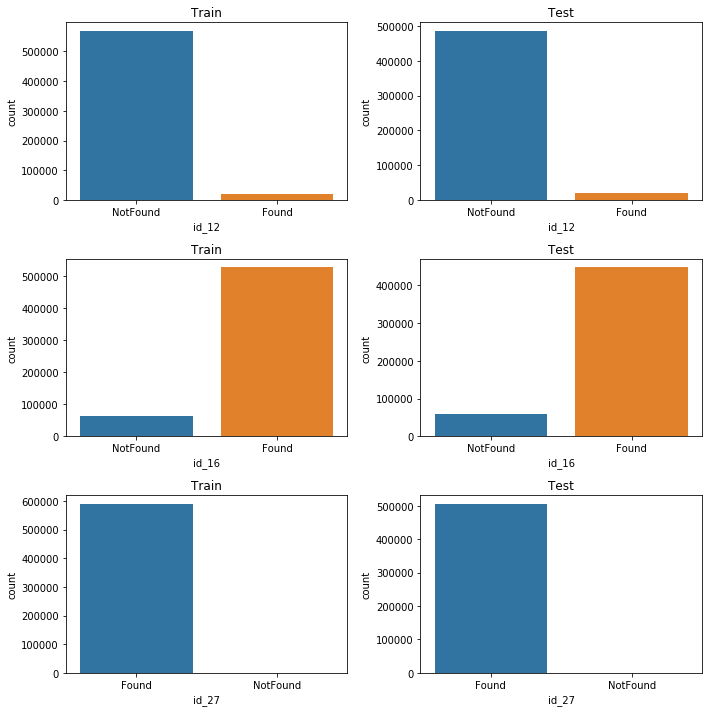

In [25]:
obj_cols=[col for col in train_df.columns if train_df[col].dtype=='object']

fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[obj_cols[i*2+j]],ax=ax[i,j])
    sns.countplot(test_df[obj_cols[i*2+j]],ax=ax[i,j+1])
    ax[i,j].set_title('Train')
    ax[i,j+1].set_title('Test')
    ax[i,j].set_xlabel(obj_cols[i*2+j])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j])
    
plt.tight_layout()    
plt.show()

All the distributions are similar in train and test

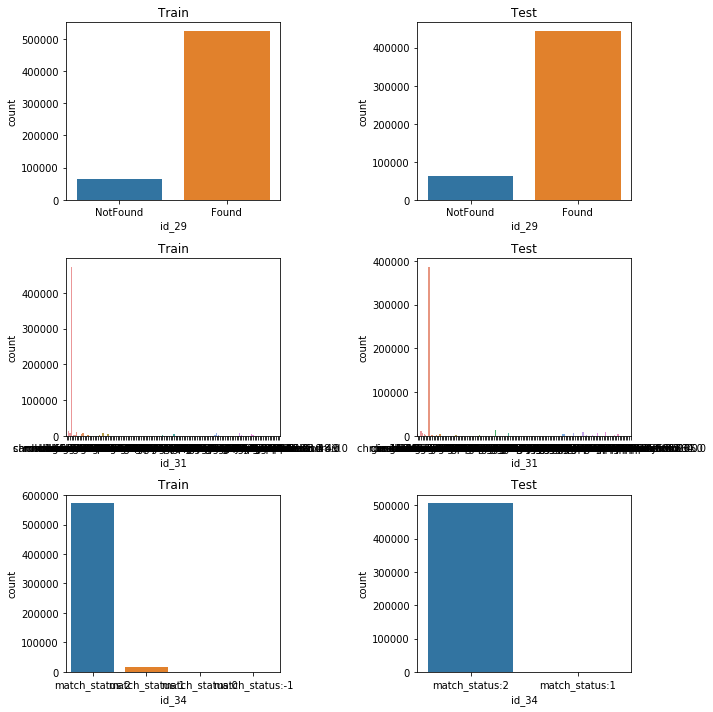

In [26]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[obj_cols[i*2+j+6]],ax=ax[i,j])
    sns.countplot(test_df[obj_cols[i*2+j+6]],ax=ax[i,j+1])
    ax[i,j].set_title('Train')
    ax[i,j+1].set_title('Test')
    ax[i,j].set_xlabel(obj_cols[i*2+j+6])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+6])
    
plt.tight_layout()    
plt.show()

id_31 has too many unique values. id_34 has more unique values in train than in test. We do similar analysis for rest of the categorical features.

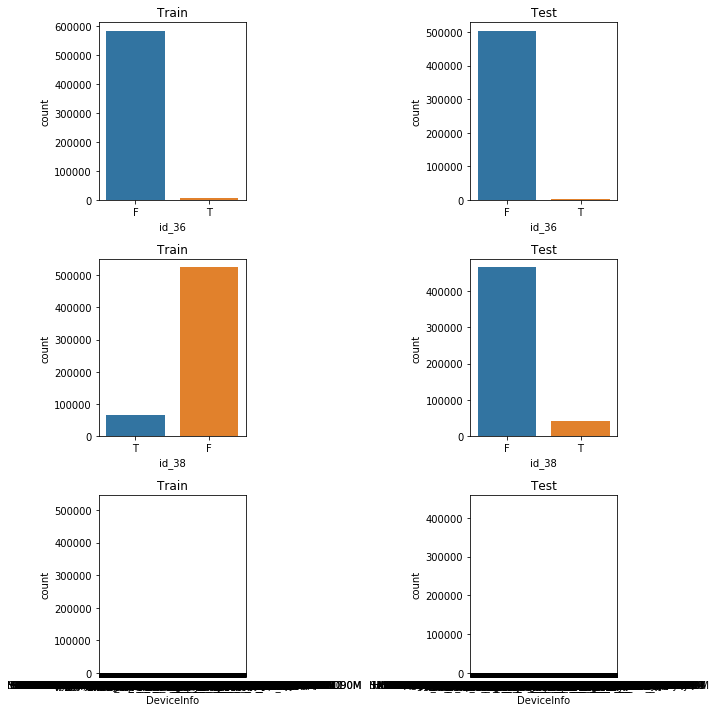

In [27]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[obj_cols[i*2+j+12]],ax=ax[i,j])
    sns.countplot(test_df[obj_cols[i*2+j+12]],ax=ax[i,j+1])
    ax[i,j].set_title('Train')
    ax[i,j+1].set_title('Test')
    ax[i,j].set_xlabel(obj_cols[i*2+j+12])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+12])
    
plt.tight_layout()    
plt.show()

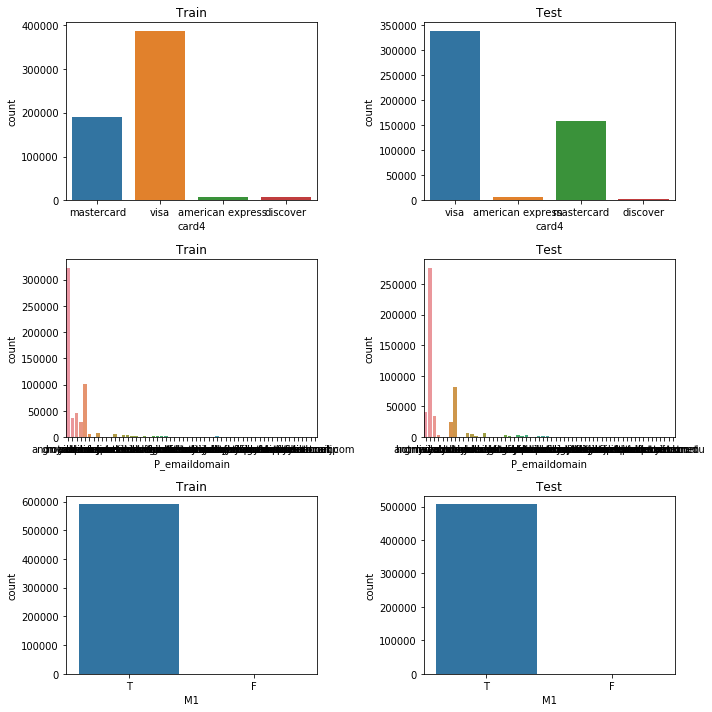

In [28]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[obj_cols[i*2+j+18]],ax=ax[i,j])
    sns.countplot(test_df[obj_cols[i*2+j+18]],ax=ax[i,j+1])
    ax[i,j].set_title('Train')
    ax[i,j+1].set_title('Test')
    ax[i,j].set_xlabel(obj_cols[i*2+j+18])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+18])
    
plt.tight_layout()    
plt.show()

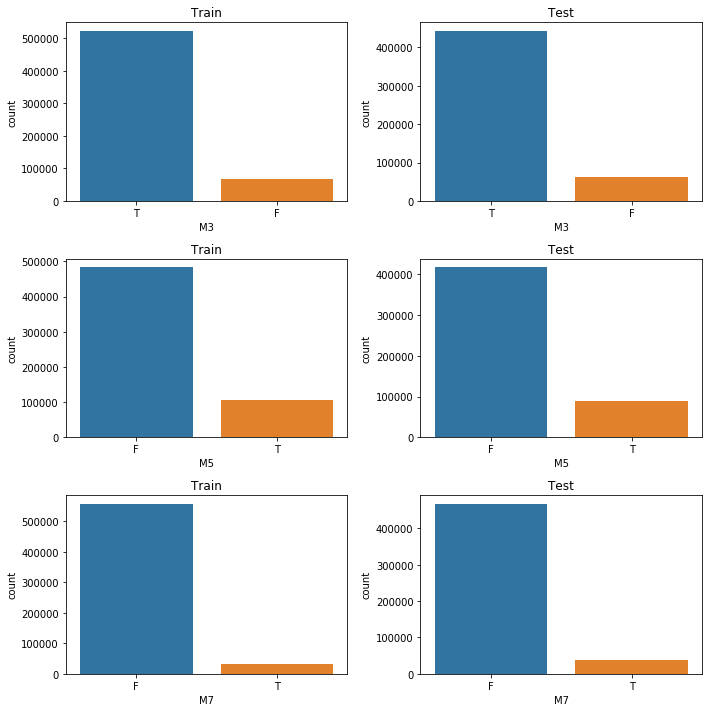

In [29]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[obj_cols[i*2+j+24]],ax=ax[i,j])
    sns.countplot(test_df[obj_cols[i*2+j+24]],ax=ax[i,j+1])
    ax[i,j].set_title('Train')
    ax[i,j+1].set_title('Test')
    ax[i,j].set_xlabel(obj_cols[i*2+j+24])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+24])
    
plt.tight_layout()    
plt.show()

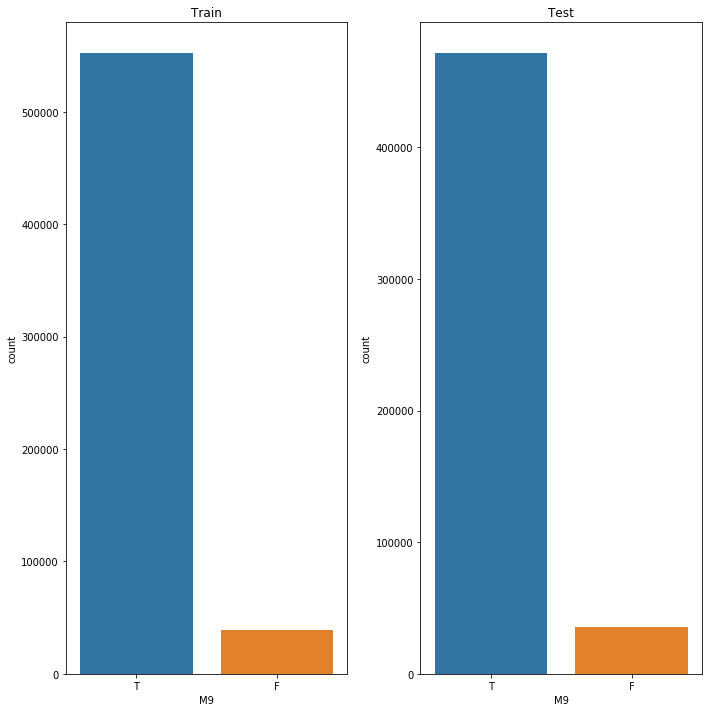

In [30]:
fig,ax=plt.subplots(1,2,figsize=(10,10))

sns.countplot(train_df[obj_cols[30]],ax=ax[0])
sns.countplot(test_df[obj_cols[30]],ax=ax[1])
ax[0].set_title('Train')
ax[1].set_title('Test')
ax[0].set_xlabel(obj_cols[30])
ax[1].set_xlabel(obj_cols[30])
    
plt.tight_layout()    
plt.show()

**Visualizing all numerical features for Fraudulent and Non-Fraudulent transactions.**

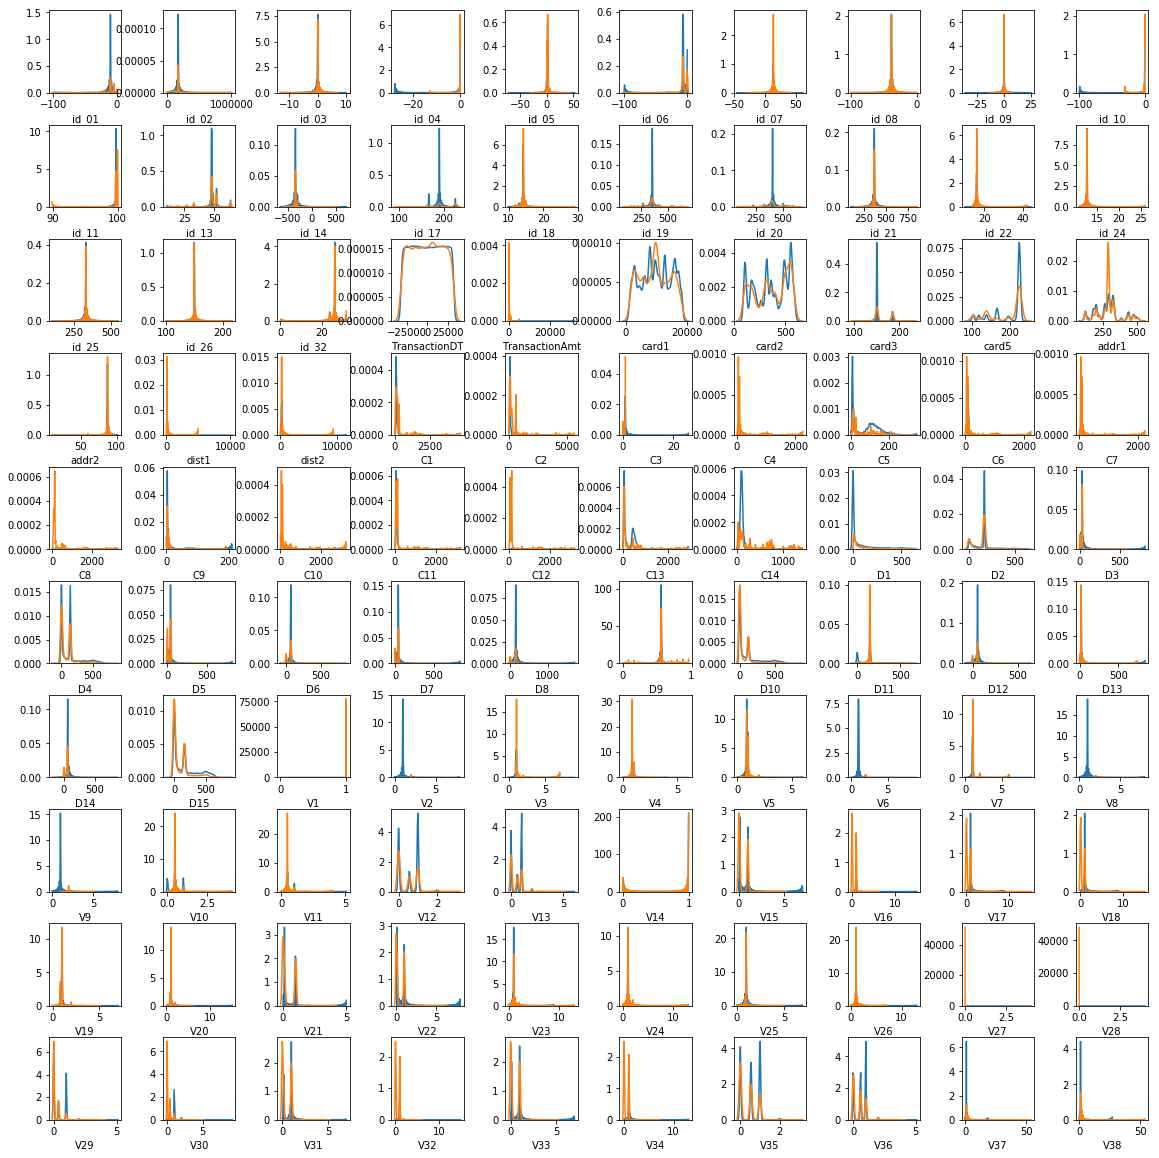

In [31]:
#Blue represents Non Fraud while orange represents Fraud
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[train_df['isFraud']==0][num_cols[i*10+j]],ax=ax[i,j],hist=False)
        sns.distplot(train_df[train_df['isFraud']==1][num_cols[i*10+j]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j])
        
        

plt.show()

Here again, we try to find features which have similar and features which have different distributions in case of Fraudulent and Non-Fraudulent data. In many cases, Fraudulent data(orange) features have sharply peaked distributions. 

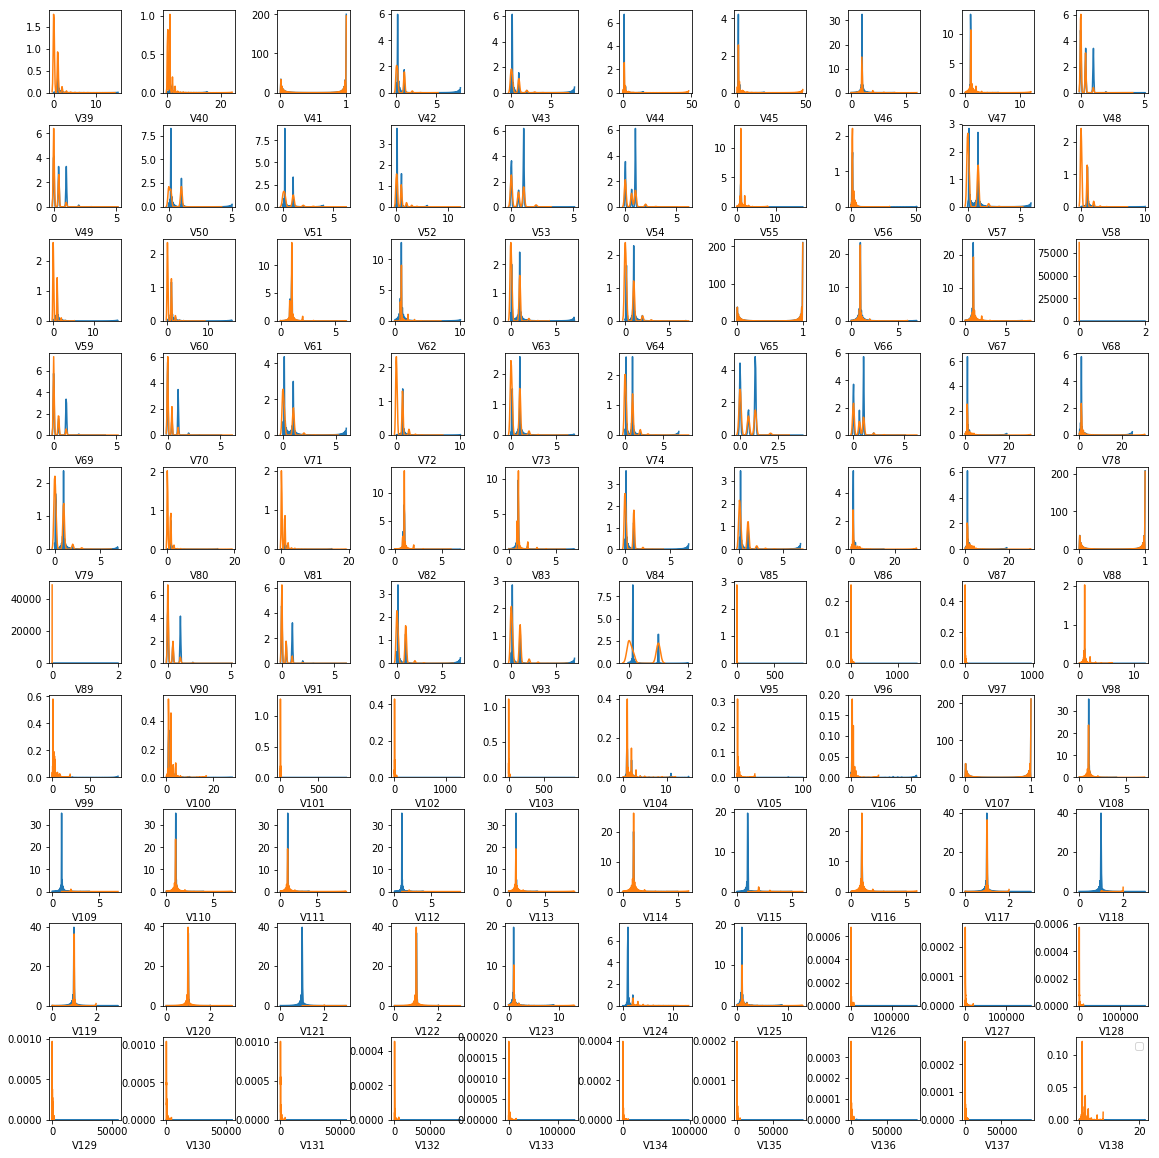

In [32]:
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[train_df['isFraud']==0][num_cols[i*10+j+100]],ax=ax[i,j],hist=False)
        sns.distplot(train_df[train_df['isFraud']==1][num_cols[i*10+j+100]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j+100])
        plt.legend()
        

plt.show()

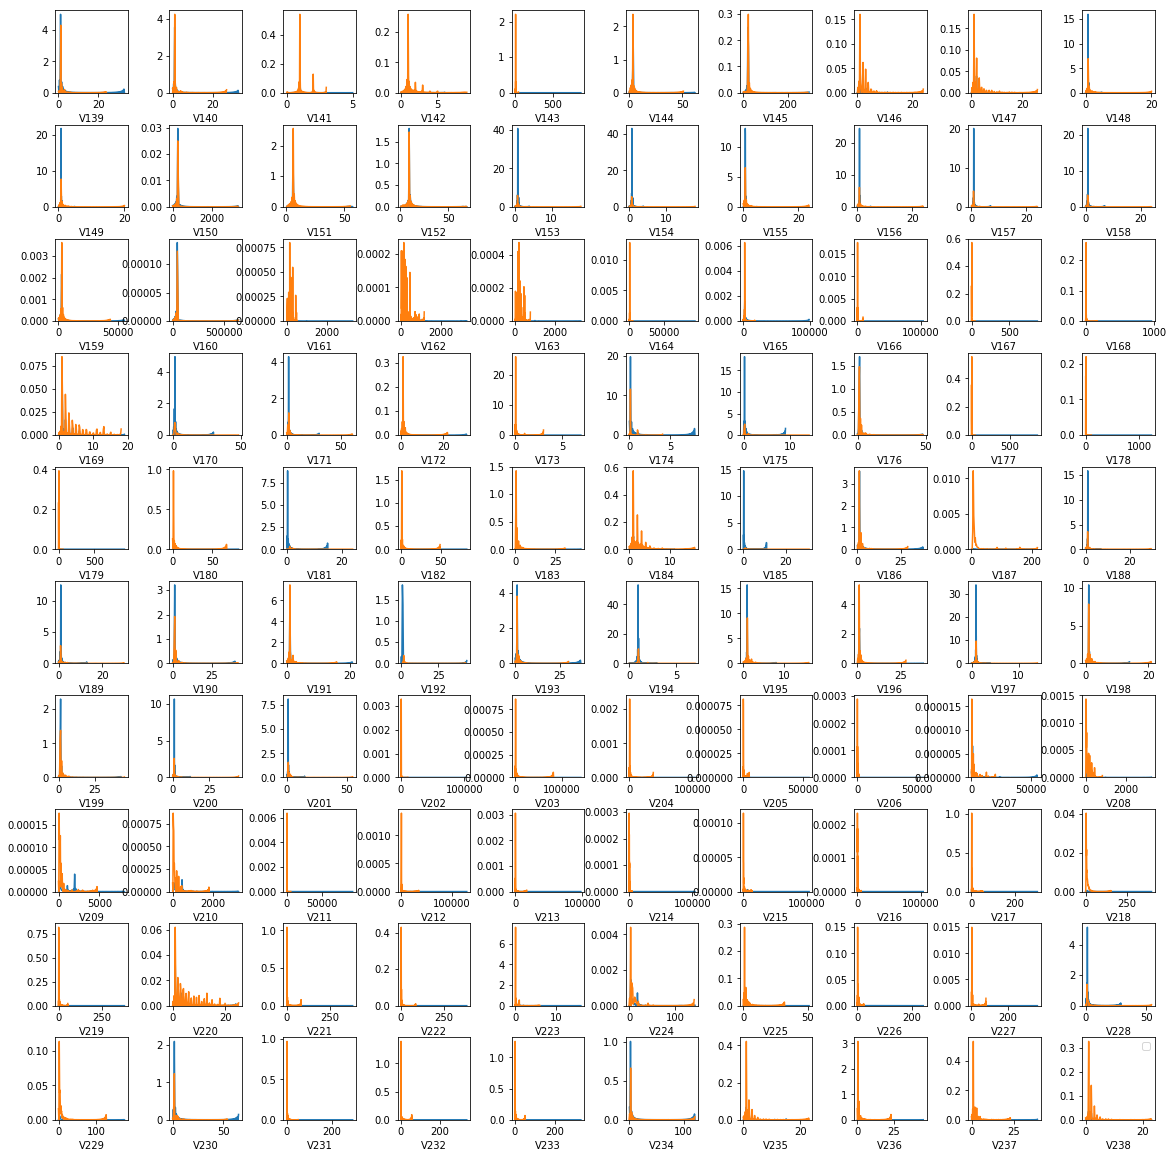

In [33]:
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[train_df['isFraud']==0][num_cols[i*10+j+200]],ax=ax[i,j],hist=False)
        sns.distplot(train_df[train_df['isFraud']==1][num_cols[i*10+j+200]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j+200])
        plt.legend()
        

plt.show()

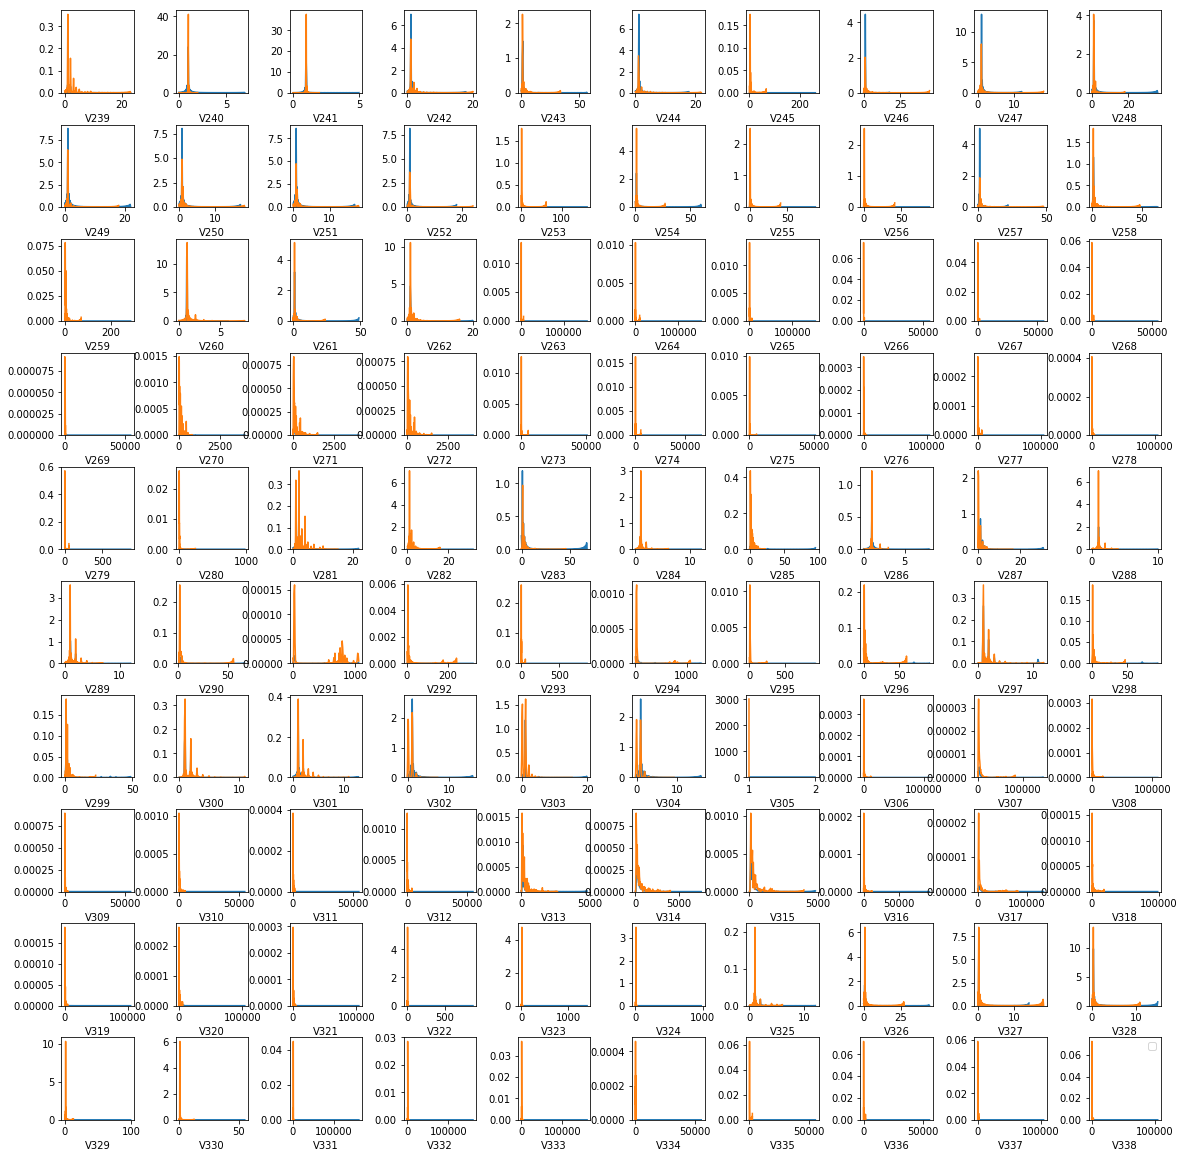

In [34]:
fig,ax=plt.subplots(10,10,figsize=(16,16))
plt.tight_layout()
for i in range(10):
    for j in range(10):
        sns.distplot(train_df[train_df['isFraud']==0][num_cols[i*10+j+300]],ax=ax[i,j],hist=False)
        sns.distplot(train_df[train_df['isFraud']==1][num_cols[i*10+j+300]],ax=ax[i,j],hist=False)
        ax[i,j].set_xlabel(num_cols[i*10+j+300])
        plt.legend()
        

plt.show()


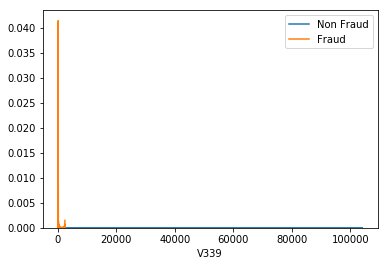

In [35]:
sns.distplot(train_df[train_df['isFraud']==0]['V339'],hist=False,label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['V339'],hist=False,label='Fraud')
plt.legend()
plt.xlabel('V339')
plt.show()

**Visualizing all categorical features for Fraud and Non-Fraudulent transactions.**

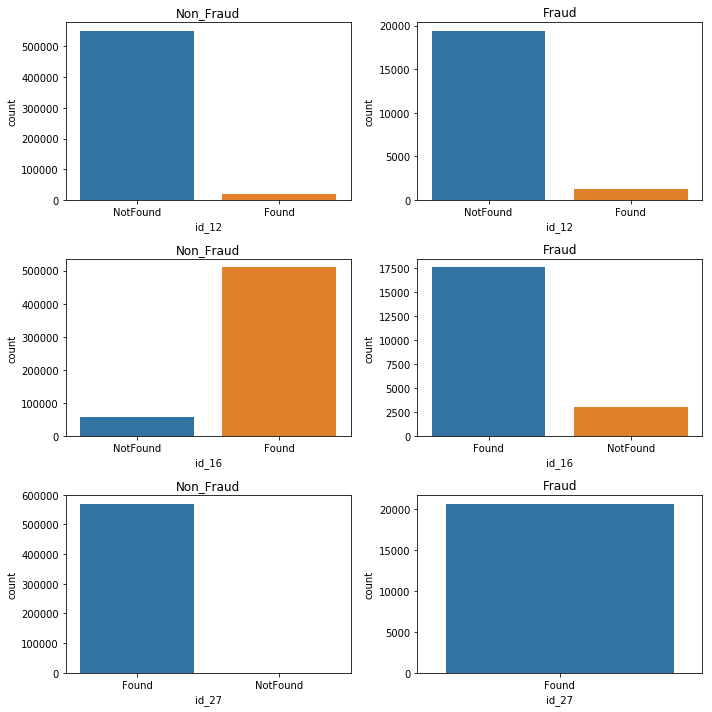

In [36]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[train_df['isFraud']==0][obj_cols[i*2+j]],ax=ax[i,j])
    sns.countplot(train_df[train_df['isFraud']==1][obj_cols[i*2+j]],ax=ax[i,j+1])
    ax[i,j].set_title('Non_Fraud')
    ax[i,j+1].set_title('Fraud')
    ax[i,j].set_xlabel(obj_cols[i*2+j])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j])
    
plt.tight_layout()    
plt.show()

Distribution of unique values of id_16 is different in Fraudulent and Non-Fraudulent transactions. id 27 has only 1 unique in case of Fraudulent transactions. We do similar analysis for further categorical features.

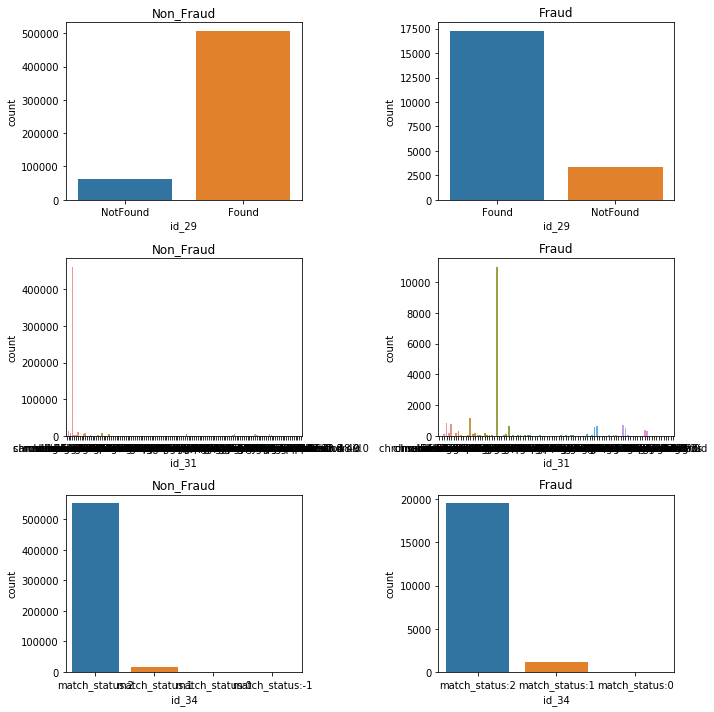

In [37]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[train_df['isFraud']==0][obj_cols[i*2+j+6]],ax=ax[i,j])
    sns.countplot(train_df[train_df['isFraud']==1][obj_cols[i*2+j+6]],ax=ax[i,j+1])
    ax[i,j].set_title('Non_Fraud')
    ax[i,j+1].set_title('Fraud')
    ax[i,j].set_xlabel(obj_cols[i*2+j+6])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+6])
    
plt.tight_layout()    
plt.show()

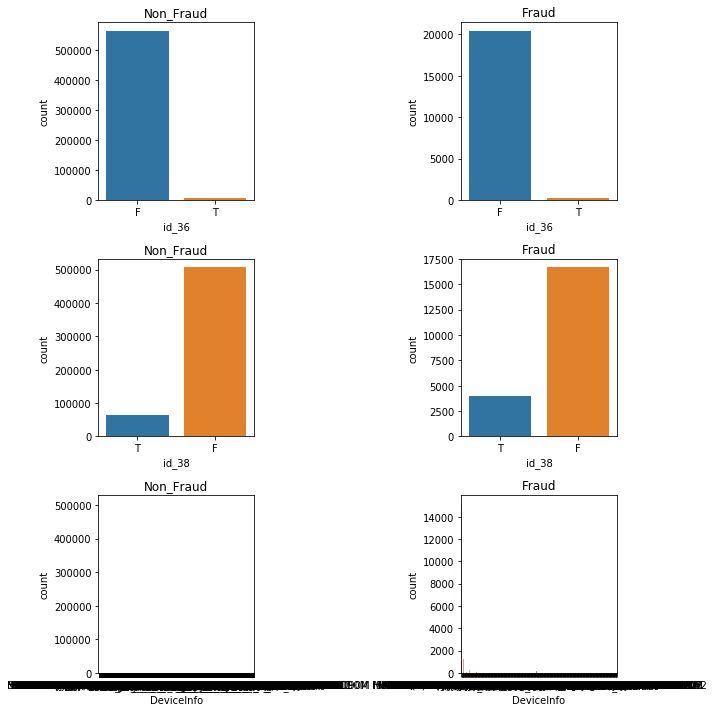

In [38]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[train_df['isFraud']==0][obj_cols[i*2+j+12]],ax=ax[i,j])
    sns.countplot(train_df[train_df['isFraud']==1][obj_cols[i*2+j+12]],ax=ax[i,j+1])
    ax[i,j].set_title('Non_Fraud')
    ax[i,j+1].set_title('Fraud')
    ax[i,j].set_xlabel(obj_cols[i*2+j+12])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+12])
    
plt.tight_layout()    
plt.show()

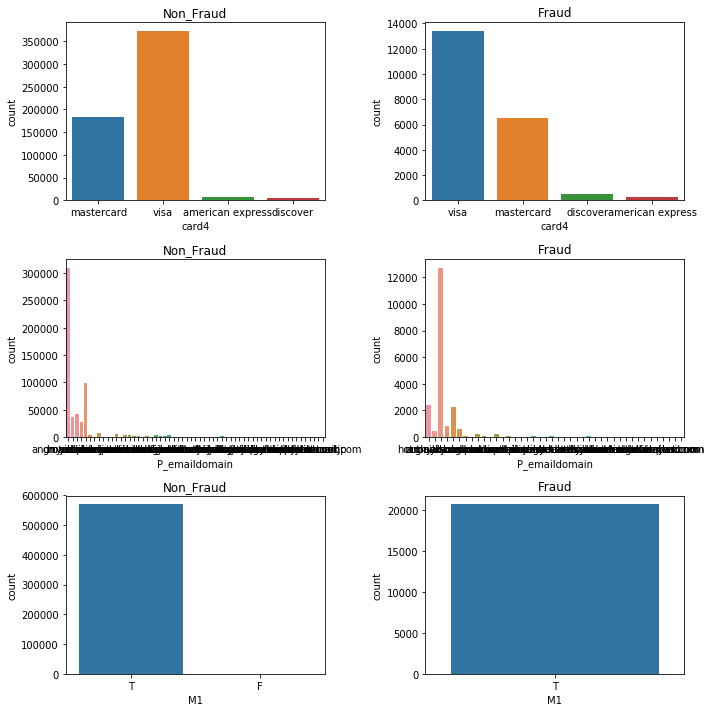

In [39]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[train_df['isFraud']==0][obj_cols[i*2+j+18]],ax=ax[i,j])
    sns.countplot(train_df[train_df['isFraud']==1][obj_cols[i*2+j+18]],ax=ax[i,j+1])
    ax[i,j].set_title('Non_Fraud')
    ax[i,j+1].set_title('Fraud')
    ax[i,j].set_xlabel(obj_cols[i*2+j+18])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+18])
    
plt.tight_layout()    
plt.show()

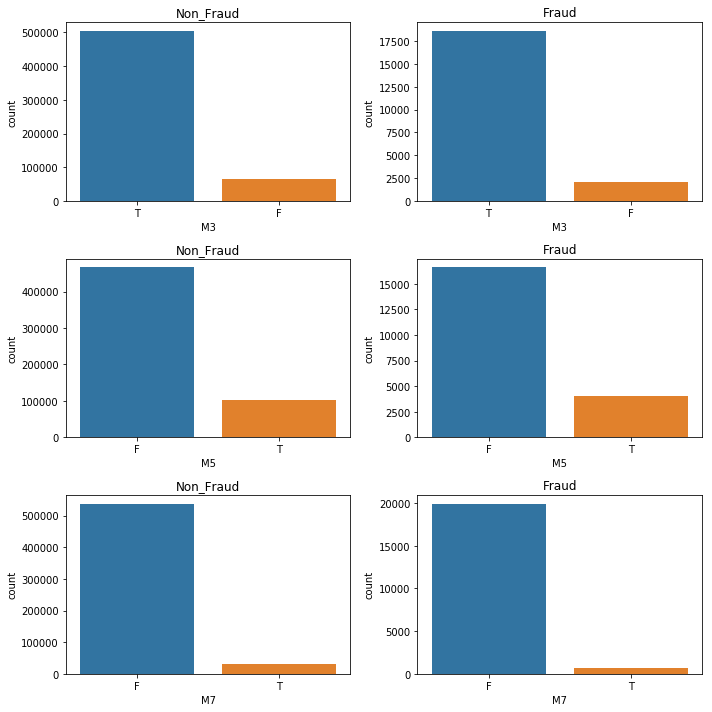

In [40]:
fig,ax=plt.subplots(3,2,figsize=(10,10))

for i in range(3):
    j=0
    sns.countplot(train_df[train_df['isFraud']==0][obj_cols[i*2+j+24]],ax=ax[i,j])
    sns.countplot(train_df[train_df['isFraud']==1][obj_cols[i*2+j+24]],ax=ax[i,j+1])
    ax[i,j].set_title('Non_Fraud')
    ax[i,j+1].set_title('Fraud')
    ax[i,j].set_xlabel(obj_cols[i*2+j+24])
    ax[i,j+1].set_xlabel(obj_cols[i*2+j+24])
    
plt.tight_layout()    
plt.show()

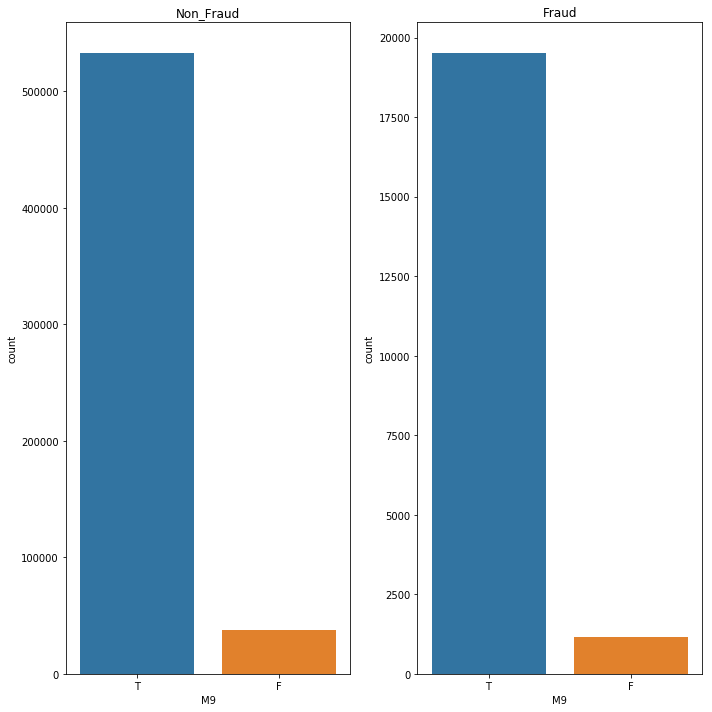

In [41]:
fig,ax=plt.subplots(1,2,figsize=(10,10))

sns.countplot(train_df[train_df['isFraud']==0][obj_cols[30]],ax=ax[0])
sns.countplot(train_df[train_df['isFraud']==1][obj_cols[30]],ax=ax[1])
ax[0].set_title('Non_Fraud')
ax[1].set_title('Fraud')
ax[0].set_xlabel(obj_cols[30])
ax[1].set_xlabel(obj_cols[30])
    
plt.tight_layout()    
plt.show()

**Visualization of new engineered features**

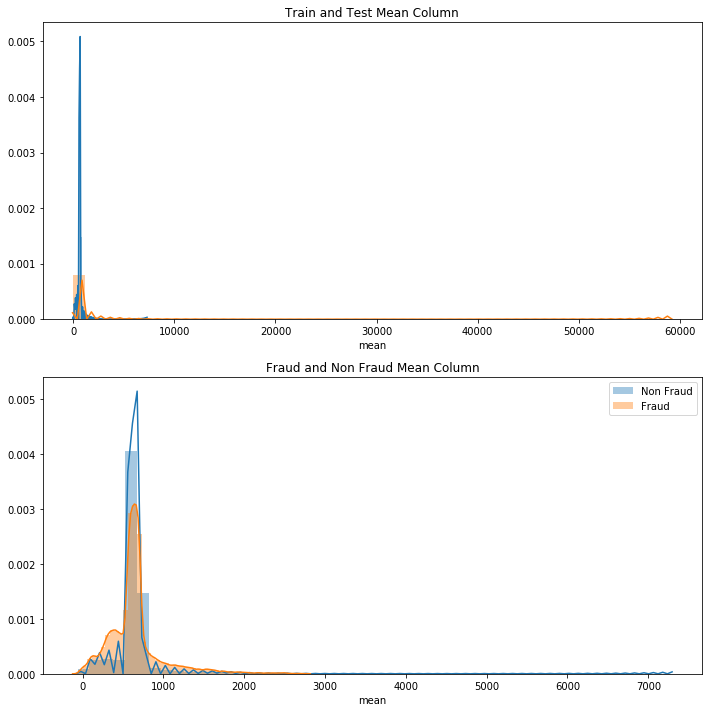

In [42]:
fig,ax=plt.subplots(2,1,figsize=(10,10))
sns.distplot(train_df['mean'],ax=ax[0],label='train')
sns.distplot(test_df['mean'],ax=ax[0],label='test')
ax[0].set_title('Train and Test Mean Column')
plt.legend()


sns.distplot(train_df[train_df['isFraud']==0]['mean'],ax=ax[1],label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['mean'],ax=ax[1],label='Fraud')
ax[1].set_title('Fraud and Non Fraud Mean Column')
plt.legend()

plt.tight_layout()
plt.show()

Similar distributions for train-test as well as for fraud-nonfraud combo.

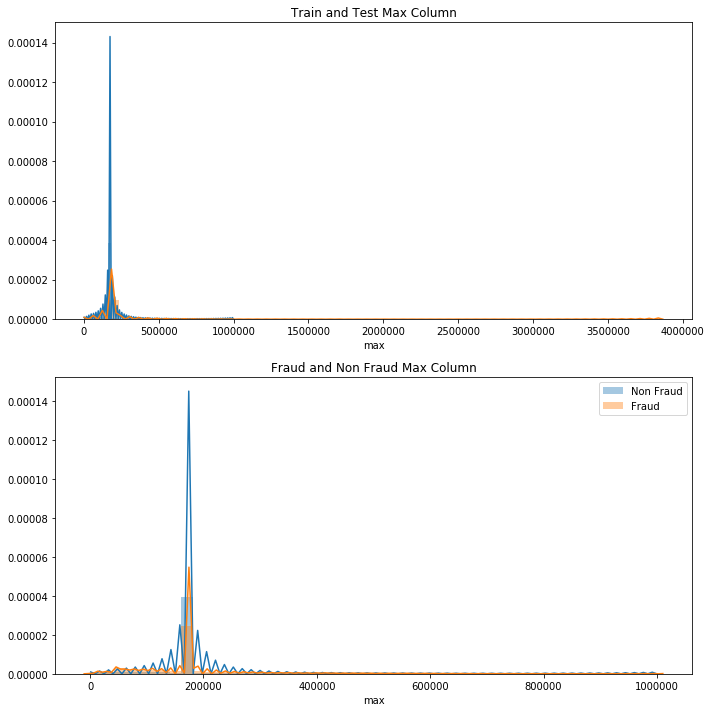

In [43]:
fig,ax=plt.subplots(2,1,figsize=(10,10))
sns.distplot(train_df['max'],ax=ax[0],label='train')
sns.distplot(test_df['max'],ax=ax[0],label='test')
ax[0].set_title('Train and Test Max Column')
plt.legend()

sns.distplot(train_df[train_df['isFraud']==0]['max'],ax=ax[1],label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['max'],ax=ax[1],label='Fraud')
ax[1].set_title('Fraud and Non Fraud Max Column')
plt.legend()

plt.tight_layout()
plt.show()

Similar .

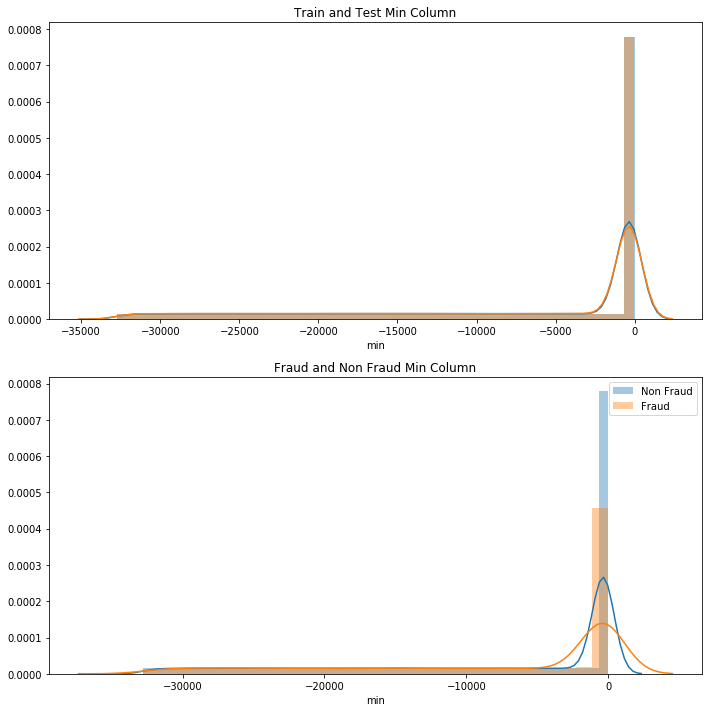

In [44]:
fig,ax=plt.subplots(2,1,figsize=(10,10))
sns.distplot(train_df['min'],ax=ax[0],label='train')
sns.distplot(test_df['min'],ax=ax[0],label='test')
ax[0].set_title('Train and Test Min Column')
plt.legend()

sns.distplot(train_df[train_df['isFraud']==0]['min'],ax=ax[1],label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['min'],ax=ax[1],label='Fraud')
ax[1].set_title('Fraud and Non Fraud Min Column')
plt.legend()

plt.tight_layout()
plt.show()

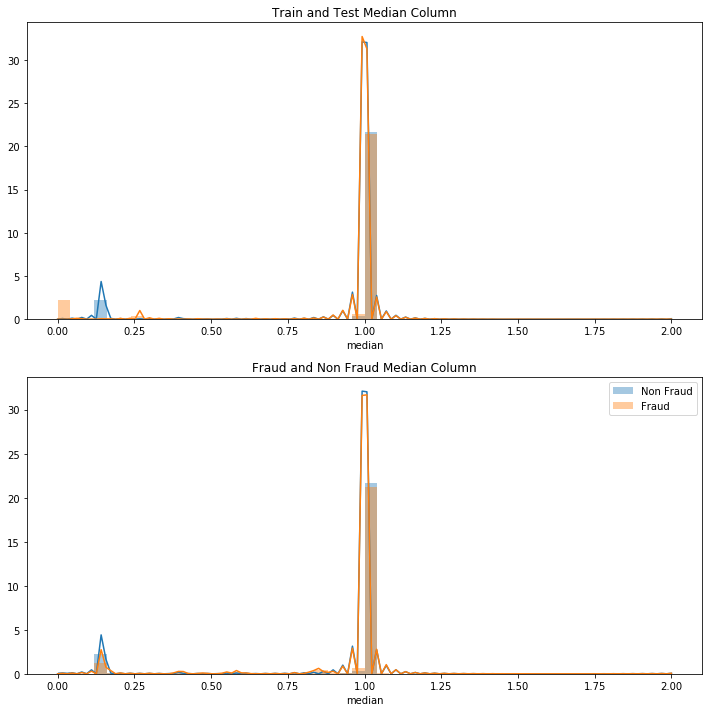

In [45]:
fig,ax=plt.subplots(2,1,figsize=(10,10))
sns.distplot(train_df['median'],ax=ax[0],label='train')
sns.distplot(test_df['median'],ax=ax[0],label='test')
ax[0].set_title('Train and Test Median Column')
plt.legend()

sns.distplot(train_df[train_df['isFraud']==0]['median'],ax=ax[1],label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['median'],ax=ax[1],label='Fraud')
ax[1].set_title('Fraud and Non Fraud Median Column')
plt.legend()

plt.tight_layout()
plt.show()

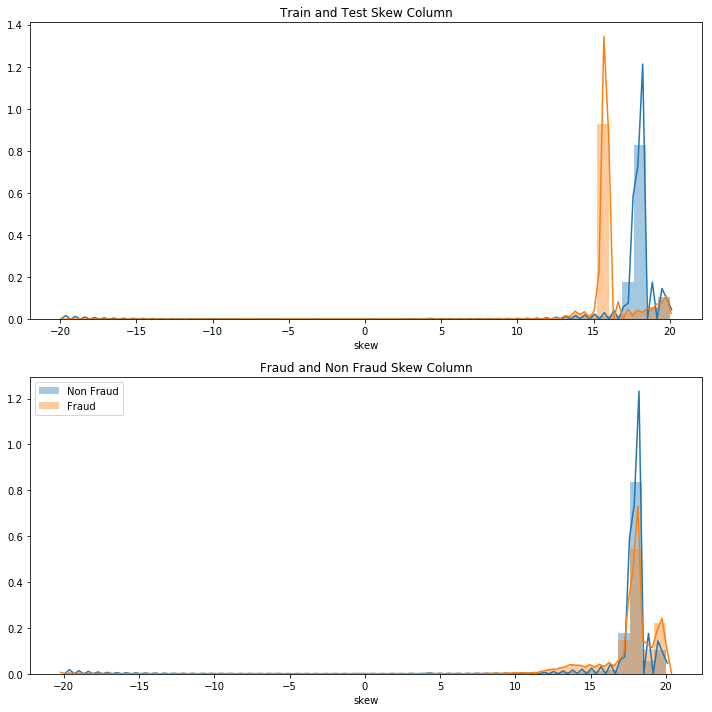

In [46]:
fig,ax=plt.subplots(2,1,figsize=(10,10))
sns.distplot(train_df['skew'],ax=ax[0],label='train')
sns.distplot(test_df['skew'],ax=ax[0],label='test')
ax[0].set_title('Train and Test Skew Column')
plt.legend()

sns.distplot(train_df[train_df['isFraud']==0]['skew'],ax=ax[1],label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['skew'],ax=ax[1],label='Fraud')
ax[1].set_title('Fraud and Non Fraud Skew Column')
plt.legend()

plt.tight_layout()
plt.show()

Train and test skewness is a bit shifted. 

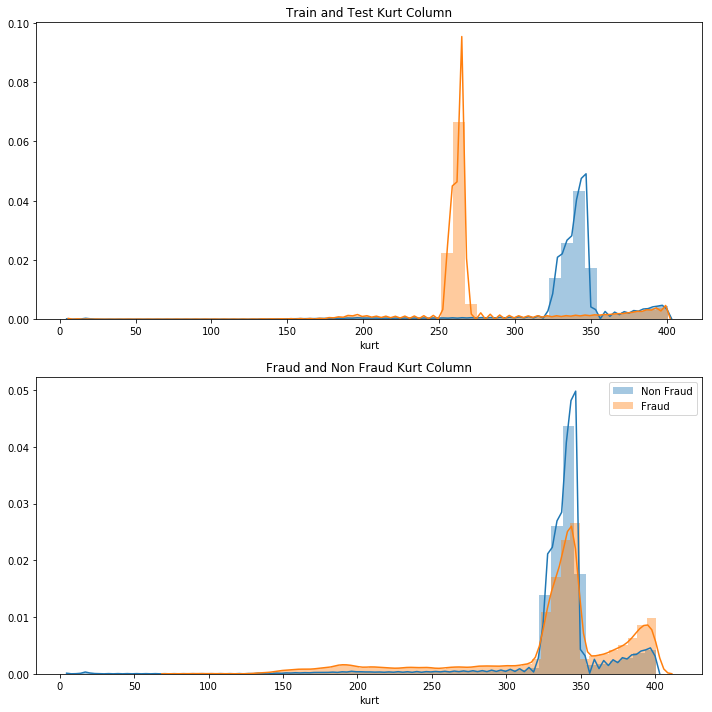

In [47]:
fig,ax=plt.subplots(2,1,figsize=(10,10))
sns.distplot(train_df['kurt'],ax=ax[0],label='train')
sns.distplot(test_df['kurt'],ax=ax[0],label='test')
ax[0].set_title('Train and Test Kurt Column')
plt.legend()

sns.distplot(train_df[train_df['isFraud']==0]['kurt'],ax=ax[1],label='Non Fraud')
sns.distplot(train_df[train_df['isFraud']==1]['kurt'],ax=ax[1],label='Fraud')
ax[1].set_title('Fraud and Non Fraud Kurt Column')
plt.legend()

plt.tight_layout()
plt.show()

The kurtosis is shifted as well.